# 10 — M1: protein-conditioned binding & the fair baseline

**What.** How to condition (concat → FiLM → cross-attn → per-residue), which objective makes the protein load-bearing (bidir-N2), and — the decisive M1 question — **does conditioning actually beat an RNA-only baseline** (not just a protein-shuffle).

**Why.** This is the most significant M1 result: it scrutinises the multimodal gain against a proper baseline and a leakage control, so the headline is honest.

**Data (Moyon/Marsico lab).** Frozen PARNET `parnet.7m-0.0`, lab binding `binding/{pureclip,narrowpeak_intersect}`, full-223 `encode.filtered.hfds`, ESM/ProtT5/per-residue/STRING, ATtRACT domains. All numbers from committed `mmpartnet_out/*.json`; figures via the reusable `scripts/viz.py` builders, so the same notebook re-plots any teammate's same-schema results. **In-distribution** (all-223 PARNET) unless noted; leave-out PARNET is the decisive follow-up.

**Builds on.** Christoph's early-fusion (= `concat` on PARNET features) + gudiyi's PARNET-eval framing.

## Definitions

With RNA features $g_r$/$H$ and protein rep $e$: **concat** $\mathrm{MLP}([g_r;e])$; **FiLM** $\gamma(e)\odot g_r+\beta(e)$; **cross-attn** $\mathrm{softmax}(QK^\top/\sqrt d)V$; **per-residue** RNA×protein-residues. Per-RBP **multimodal gap** $\delta_g=\mathrm{auPRC}(g|e_g)-\mathrm{auPRC}(g|e_{\pi(g)})$ (derangement $\pi$). Objective on the N2 protein-discriminative task: BCE vs the bidirectional contrastive loss. Fair test = per-RBP delta vs the **RNA-only multitask** baseline (no protein), with a **random-body** control (the gap to it = PARNET-leakage share) + a paired bootstrap CI + binomial/Wilcoxon **sign test**.

In [1]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
m=J('binding_mechanism.json'); n2=J('binding_n2_xattn.json'); f=J('binding_fair.json')
print('LADDER (gain vs shuffle):', {k: round(m['mechanisms'][k]['gap_mean'],3) for k in ['concat','film','xattn']})
print('OBJECTIVE (N2 gate):', {k: round(v['gap'],3) for k,v in n2['cells'].items()})
b=f['baselines']; print(f"FAIR baselines: RNA-only {b['rna_only_multitask']:.3f} | random-body {b['rna_only_randombody']:.3f} (leakage {f['leakage_attributable_auprc']:+.3f})")
for mth,v in f['methods'].items(): print(f"  {mth:7} vs RNA-only {v['gap_vs_rna_only']:+.4f} | {v['direction_vs_rna_only']} {v['n_beat_rna_only']}/{v['n_rbp']} (p={v['sign_test_binom_p']:.1e})")

LADDER (gain vs shuffle): {'concat': 0.04, 'film': 0.066, 'xattn': 0.081}
OBJECTIVE (N2 gate): {'xattn-bce': 0.016, 'xattn-bidir': 0.136, 'film-bidir': 0.208, 'bidir-bidir': 0.158}
FAIR baselines: RNA-only 0.106 | random-body 0.057 (leakage +0.049)
  concat  vs RNA-only -0.0213 | UNDERPERFORMS 5/68 (p=7.7e-14)
  film    vs RNA-only -0.0023 | UNDERPERFORMS 22/68 (p=4.9e-03)
  xattn   vs RNA-only +0.0103 | BEATS 35/68 (p=9.0e-01)
  perres  vs RNA-only +0.0152 | BEATS 43/68 (p=3.8e-02)


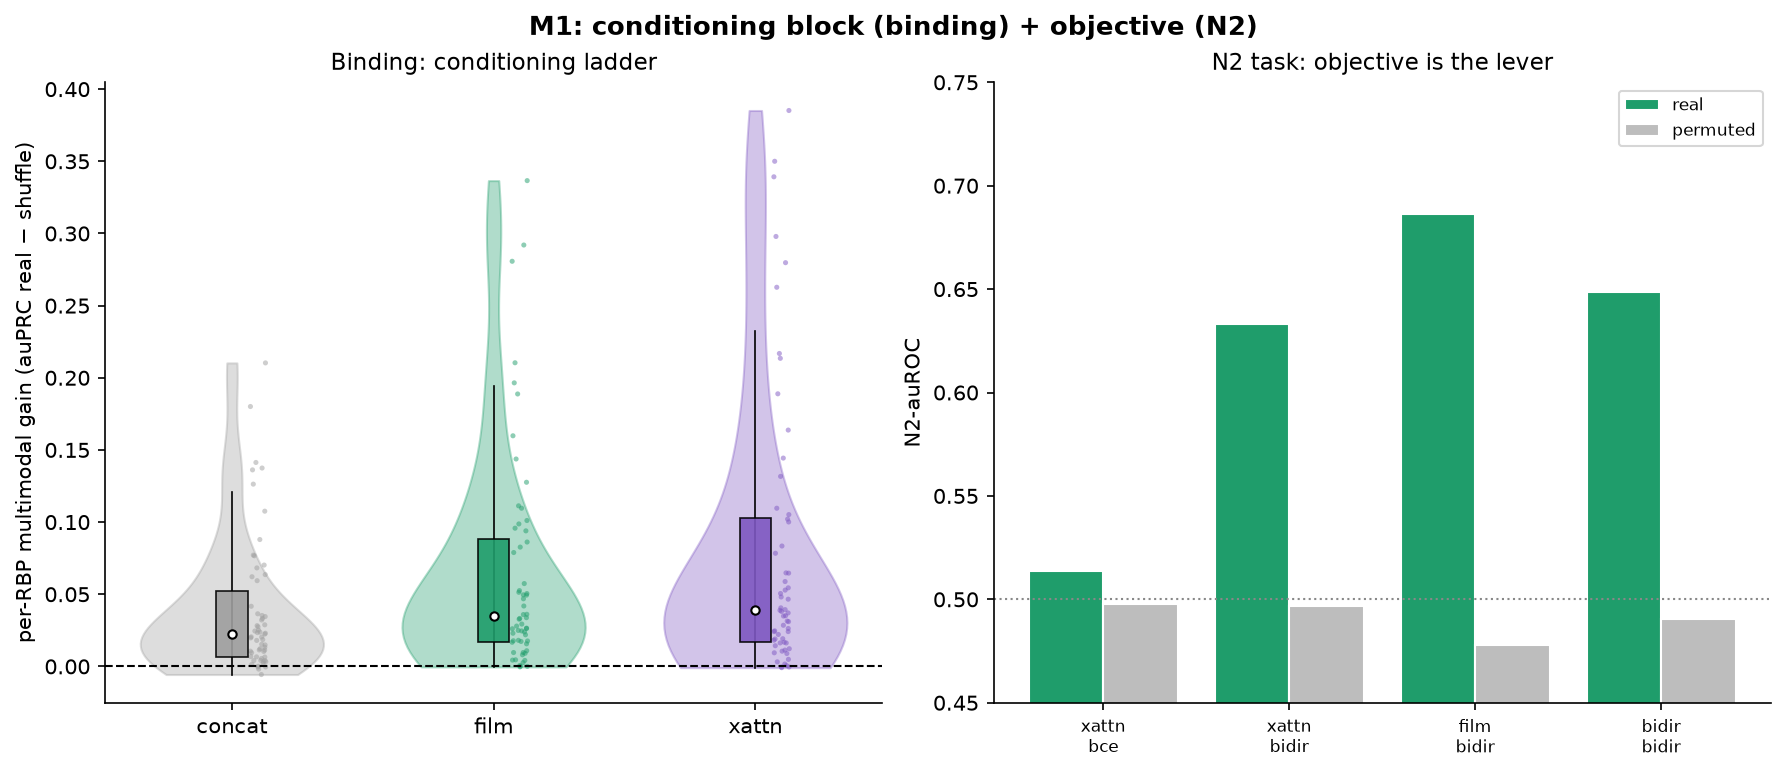

In [2]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
show(viz.fig_mechanism(J('binding_mechanism.json'), J('binding_n2_xattn.json')),'nb10_mechanism.png',
     'M1: conditioning block (binding) + objective (N2)')

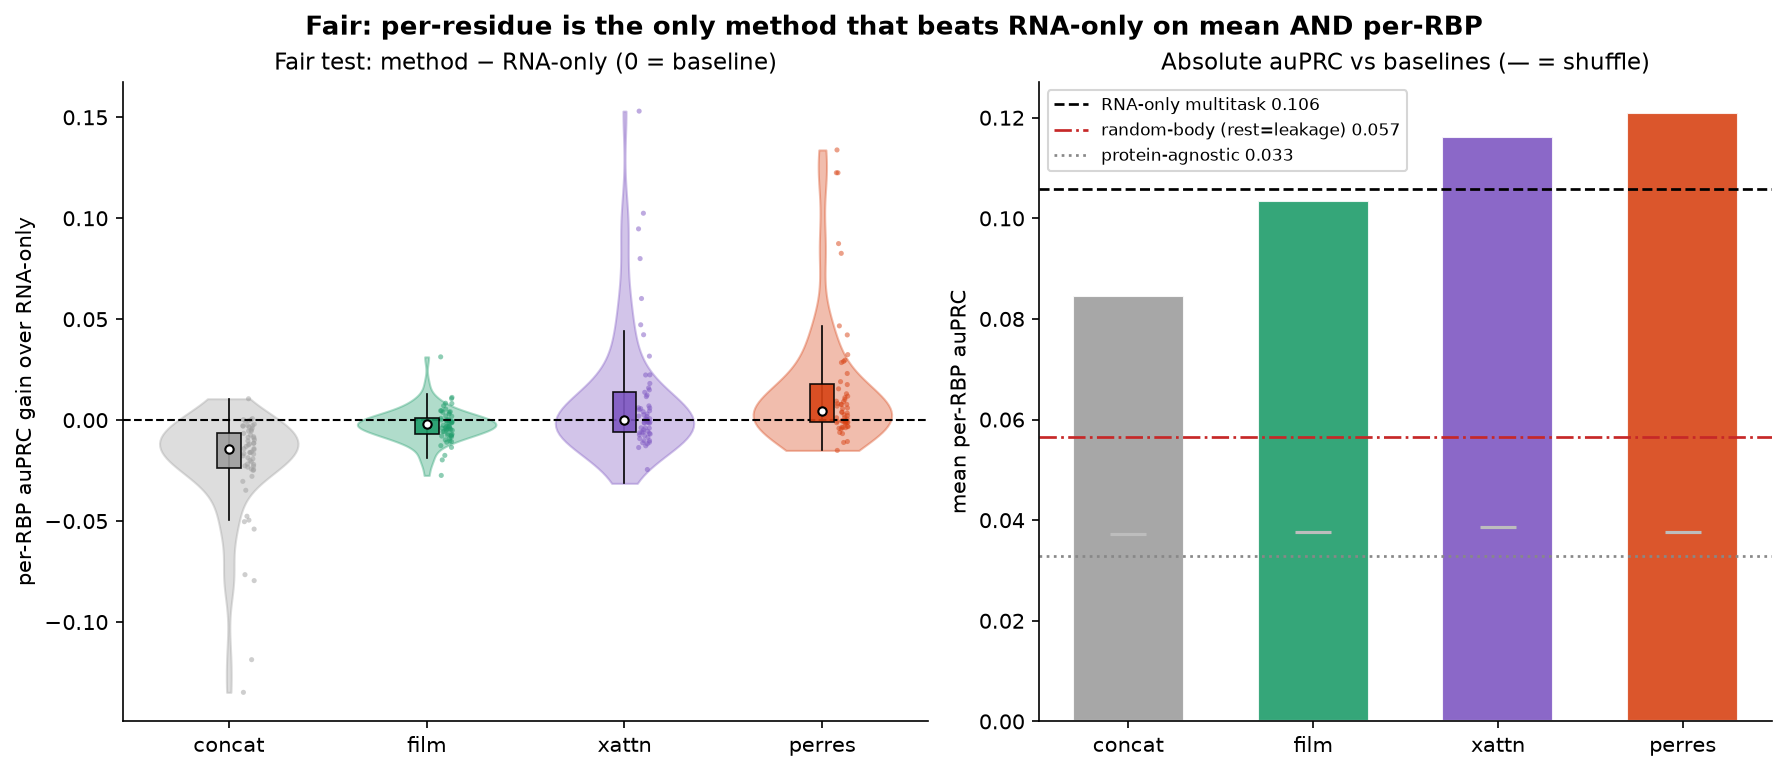

In [3]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
show(viz.fig_fair(J('binding_fair.json')),'nb10_fair.png',
     'Fair: per-residue is the only method that beats RNA-only on mean AND per-RBP')

In [4]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
f=J('binding_fair.json'); M=f['methods']; b=f['baselines']
display(Markdown(f'''**Result.** Conditioning is a ladder (concat<FiLM<cross-attn<per-residue) and the bidir-N2 objective makes the protein load-bearing. But against a proper RNA-only baseline ({b['rna_only_multitask']:.3f}, of which ~{100*f['leakage_attributable_auprc']/b['rna_only_multitask']:.0f}% is PARNET leakage per the random-body {b['rna_only_randombody']:.3f}): concat {M['concat']['gap_vs_rna_only']:+.3f} and FiLM {M['film']['gap_vs_rna_only']:+.3f} significantly underperform; cross-attn {M['xattn']['gap_vs_rna_only']:+.3f} beats on the mean but not per-RBP ({M['xattn']['n_beat_rna_only']}/{M['xattn']['n_rbp']}, p={M['xattn']['sign_test_binom_p']:.2f}); only **per-residue {M['perres']['gap_vs_rna_only']:+.3f}** beats it on both (43/68, Wilcoxon p={M['perres']['wilcoxon_p']:.0e}). All beat protein-shuffle, so protein IS useful — just overwhelmed by the leakage-inflated baseline in-distribution.'''))

**Result.** Conditioning is a ladder (concat<FiLM<cross-attn<per-residue) and the bidir-N2 objective makes the protein load-bearing. But against a proper RNA-only baseline (0.106, of which ~47% is PARNET leakage per the random-body 0.057): concat -0.021 and FiLM -0.002 significantly underperform; cross-attn +0.010 beats on the mean but not per-RBP (35/68, p=0.90); only **per-residue +0.015** beats it on both (43/68, Wilcoxon p=6e-05). All beat protein-shuffle, so protein IS useful — just overwhelmed by the leakage-inflated baseline in-distribution.

## Conclusion

| method | vs RNA-only | sign test | verdict |
|---|---|---|---|
| concat | −0.021 (CI<0) | 5/68 p=8e-14 | significantly loses |
| FiLM | −0.002 (CI<0) | 22/68 | below |
| cross-attn | +0.010 (CI>0) | 35/68 p=0.90 | mean only, not per-RBP |
| **per-residue** | **+0.015 (CI>0)** | **43/68 Wilcoxon 6e-5** | **beats RNA-only** |

Only per-residue robustly beats RNA-only; the baseline is ~half leakage. The decisive test is the same harness under leave-out PARNET (swap `ML4RG_PARNET_WEIGHTS`), where the RNA-only head loses its held-out-RBP outputs and the conditioned advantage should widen.

Claude-assisted; methods per Horlacher 2023 (RBPNet) + TFBindFormer/CORAL (cross-attention).